# 03 — Model Comparison
Load trained models and compare results with detailed visualizations.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load results
with open('../outputs/results_summary.json') as f:
    results = json.load(f)

best_model_name = results.pop('best_model')
df_results = pd.DataFrame(results).T
df_results = df_results.astype(float)
print(f'Best model: {best_model_name}')
df_results

Best model: Logistic Regression


,val_accuracy,val_precision,val_recall,val_f1,val_auc,cv_auc_mean,cv_auc_std
Logistic Regression,0.8641,0.8469,0.8925,0.8691,0.9321,0.9300,0.0233
Random Forest,0.7935,0.7723,0.8387,0.8041,0.9074,0.8992,0.0332
Gradient Boosting,0.8098,0.7900,0.8495,0.8187,0.8970,0.8926,0.0325
SVM,0.8533,0.8367,0.8817,0.8586,0.9264,0.9145,0.0385
KNN,0.7609,0.7379,0.8172,0.7755,0.8456,0.8513,0.0401


## 1. Score Comparison Table

In [2]:
styled = df_results.style\
    .background_gradient(cmap='RdYlGn', subset=['val_auc','cv_auc_mean'])\
    .background_gradient(cmap='RdYlGn', subset=['val_accuracy'])\
    .format('{:.4f}')\
    .set_caption('Model Comparison — All Metrics')
styled

,val_accuracy,val_precision,val_recall,val_f1,val_auc,cv_auc_mean,cv_auc_std
Logistic Regression,0.8641,0.8469,0.8925,0.8691,0.9321,0.9300,0.0233
Random Forest,0.7935,0.7723,0.8387,0.8041,0.9074,0.8992,0.0332
Gradient Boosting,0.8098,0.7900,0.8495,0.8187,0.8970,0.8926,0.0325
SVM,0.8533,0.8367,0.8817,0.8586,0.9264,0.9145,0.0385
KNN,0.7609,0.7379,0.8172,0.7755,0.8456,0.8513,0.0401


## 2. Bar Chart Comparison

C:\Users\elssh\AppData\Local\Temp\ipykernel_5732\3539307119.py:22: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\elssh\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


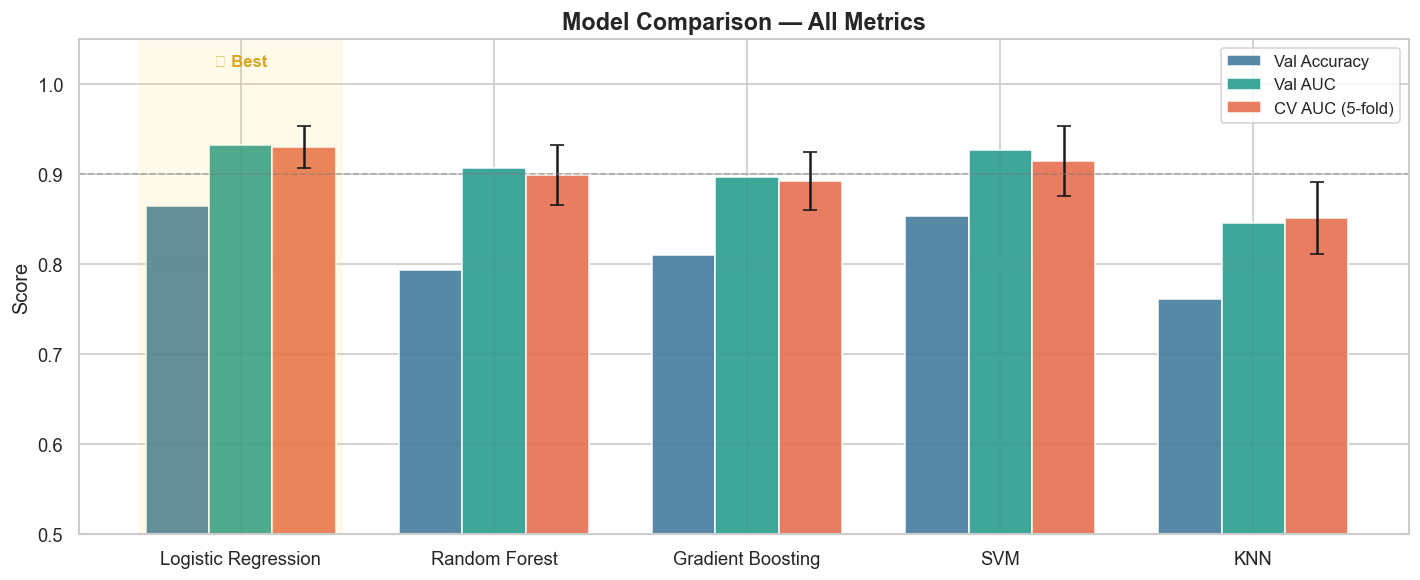

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_results))
w = 0.25
ax.bar(x - w,   df_results['val_accuracy'], w, label='Val Accuracy',    color='#457b9d', alpha=0.9)
ax.bar(x,        df_results['val_auc'],     w, label='Val AUC',         color='#2a9d8f', alpha=0.9)
ax.bar(x + w, df_results['cv_auc_mean'],   w,
       yerr=df_results['cv_auc_std'], capsize=4,
       label='CV AUC (5-fold)', color='#e76f51', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(df_results.index, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.9, ls='--', color='gray', lw=1, alpha=0.5, label='0.9 threshold')

# Highlight best
best_idx = list(df_results.index).index(best_model_name)
ax.axvspan(best_idx - 0.4, best_idx + 0.4, alpha=0.08, color='gold')
ax.text(best_idx, 1.02, '★ Best', ha='center', fontsize=10, color='goldenrod', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Load Saved Plots

--- roc_curves ---


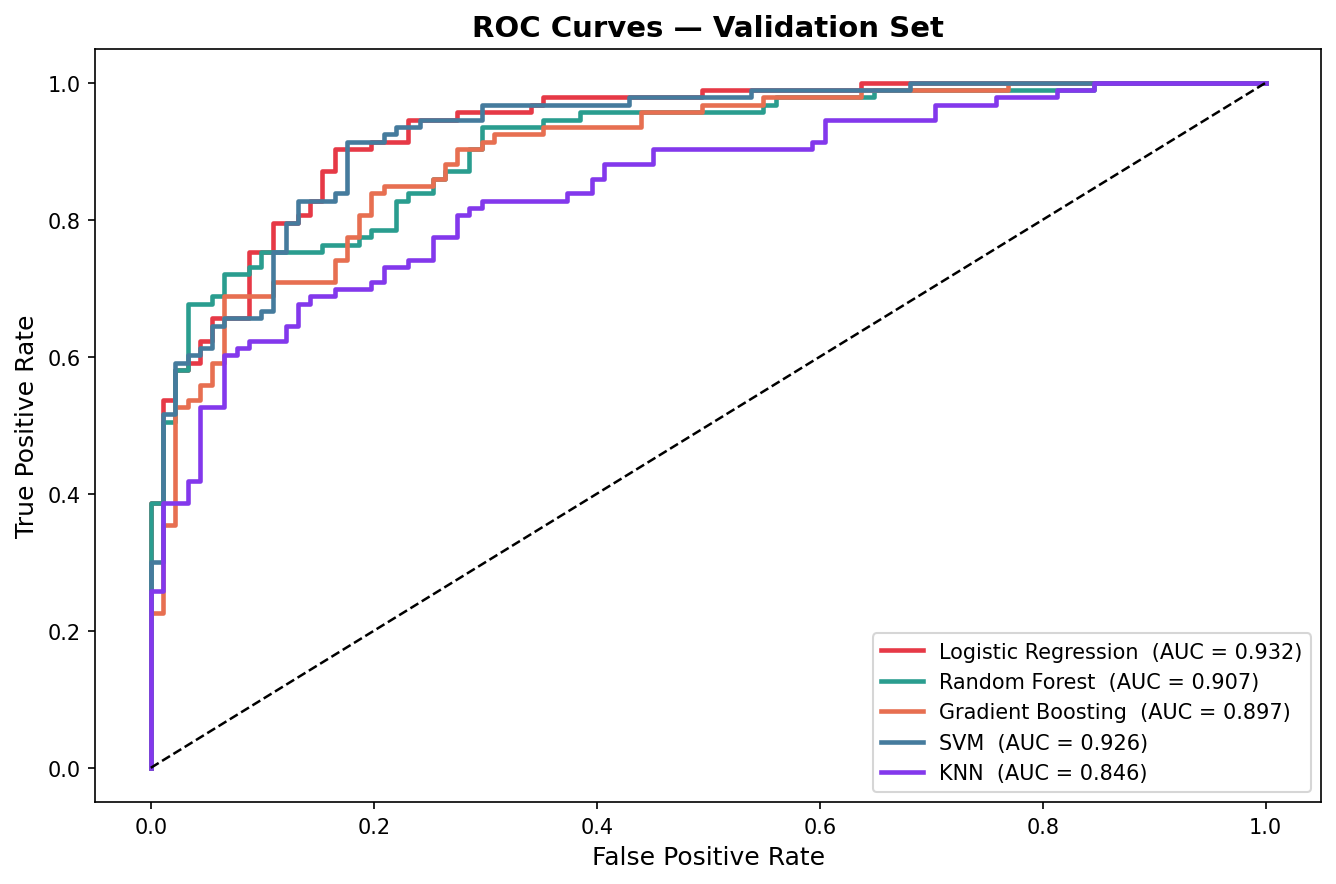

--- confusion_matrices ---


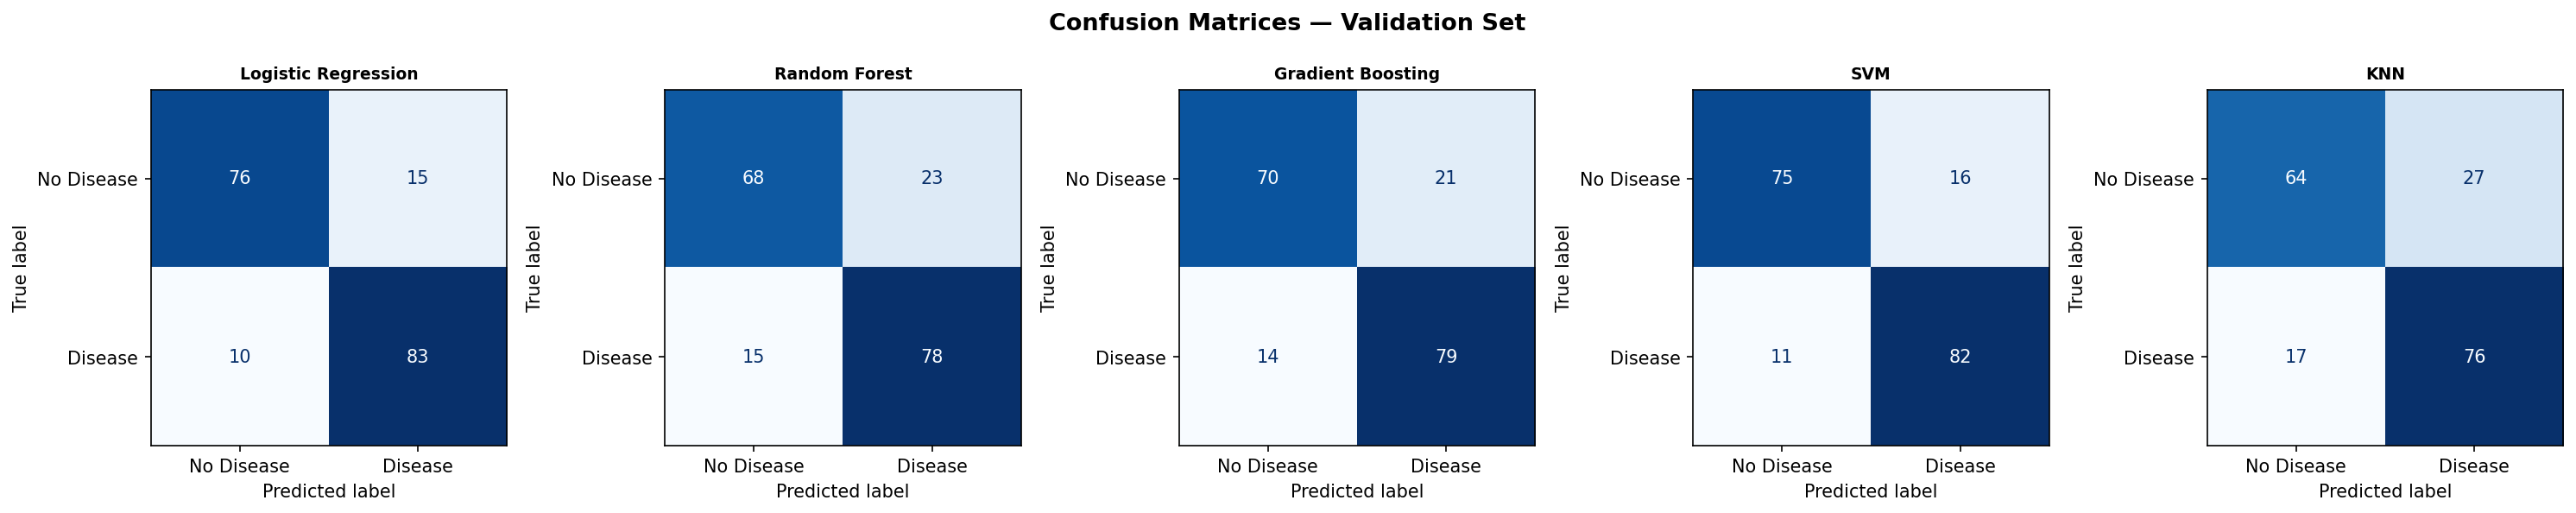

[!] ../plots/feature_importance.png not found — run train.py first


In [4]:
from IPython.display import Image, display
for plot_name in ['roc_curves', 'confusion_matrices', 'feature_importance']:
    path = f'../plots/{plot_name}.png'
    if os.path.exists(path):
        print(f'--- {plot_name} ---')
        display(Image(path))
    else:
        print(f'[!] {path} not found — run train.py first')

## 4. Bias-Variance Analysis

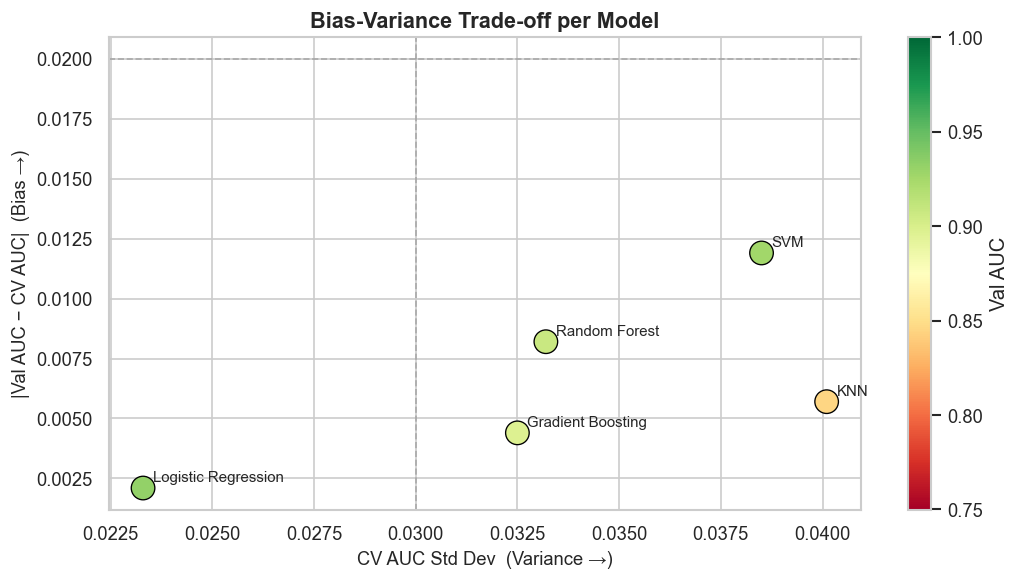

Models closest to origin (low bias + low variance) are most stable.


In [5]:
df_results['cv_val_gap'] = (df_results['val_auc'] - df_results['cv_auc_mean']).abs()

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    df_results['cv_auc_std'],
    df_results['cv_val_gap'],
    s=200, c=df_results['val_auc'],
    cmap='RdYlGn', vmin=0.75, vmax=1.0,
    edgecolors='black', linewidths=0.8
)
for name, row in df_results.iterrows():
    ax.annotate(name, (row['cv_auc_std'], row['cv_val_gap']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

plt.colorbar(scatter, ax=ax, label='Val AUC')
ax.set_xlabel('CV AUC Std Dev  (Variance →)', fontsize=11)
ax.set_ylabel('|Val AUC − CV AUC|  (Bias →)', fontsize=11)
ax.set_title('Bias-Variance Trade-off per Model', fontsize=13, fontweight='bold')
ax.axhline(0.02, ls='--', color='gray', lw=1, alpha=0.5)
ax.axvline(0.03, ls='--', color='gray', lw=1, alpha=0.5)

plt.tight_layout()
plt.show()

print('Models closest to origin (low bias + low variance) are most stable.')